# 제주도 농산물 가격 예측 심층 데이터 분석 (EDA)
2023년 03월 04일부터 2023년 03월 31일까지의 price(원/kg)을 예측

## 1. 환경 설정 및 폰트 로드

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from matplotlib import font_manager, rc
warnings.filterwarnings("ignore")

def setup_korean_font():
    import platform
    if platform.system() == "Windows":
        rc("font", family="Malgun Gothic")
    else:
        font_list = font_manager.findSystemFonts()
        for fpath in font_list:
            if "nanum" in fpath.lower() or "gothic" in fpath.lower():
                font_manager.fontManager.addfont(fpath)
                rc("font", family=font_manager.FontProperties(fname=fpath).get_name())
                break
    plt.rcParams["axes.unicode_minus"] = False
    print("폰트 설정 완료")

setup_korean_font()

폰트 설정 완료


## 2. 데이터 로드 및 컬럼 설명

In [25]:
def smart_load(name):
    for p in [name, f"jeju/{name}"]: 
        if os.path.exists(p): return pd.read_csv(p)
    return None

train = smart_load("train.csv")
test = smart_load("test.csv")
sub = smart_load("sample_submission.csv")

train["timestamp"] = pd.to_datetime(train["timestamp"])
test["timestamp"] = pd.to_datetime(test["timestamp"])
print("데이터 로드 완료")

데이터 로드 완료


### 2.1 컬럼 상세 설명
| 컬럼명 | 의미 | 타입 |
|:---|:---|:---|
| ID | 품목_법인_지역_날짜 조합 고유키 | object |
| timestamp | 거래 날짜 | datetime |
| item | 품목 (TG: 감귤, CR: 당근, CB: 양배추, RD: 무, BC: 브로콜리) | object |
| corporation | 유통 법인 (A~F) | object |
| location | 지역 (J:제주, S:서귀포) | object |
| supply(kg) | 거래 물량 | float |
| price(원/kg) | 거래 가격 (Target) | float |

## 3. 기본 정보 및 결측치 확인

In [26]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 59397 entries, 0 to 59396
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ID           59397 non-null  str           
 1   timestamp    59397 non-null  datetime64[us]
 2   item         59397 non-null  str           
 3   corporation  59397 non-null  str           
 4   location     59397 non-null  str           
 5   supply(kg)   59397 non-null  float64       
 6   price(원/kg)  59397 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(4)
memory usage: 3.2 MB


In [27]:
print("결측치 합계:", train.isnull().sum())

결측치 합계: ID             0
timestamp      0
item           0
corporation    0
location       0
supply(kg)     0
price(원/kg)    0
dtype: int64


In [28]:
display(train.describe())

,timestamp,supply(kg),price(원/kg)
count,59397,5.939700e+04,59397.000000
mean,2021-01-30 23:59:59.999999,1.189453e+04,1131.680674
min,2019-01-01 00:00:00,0.000000e+00,0.000000
25%,2020-01-16 00:00:00,0.000000e+00,0.000000
50%,2021-01-31 00:00:00,0.000000e+00,0.000000
75%,2022-02-16 00:00:00,3.800000e+03,1519.000000
max,2023-03-03 00:00:00,1.222800e+06,20909.000000
std,NaN,5.226400e+04,2029.941445


## 4. 범주형 변수 분포 분석

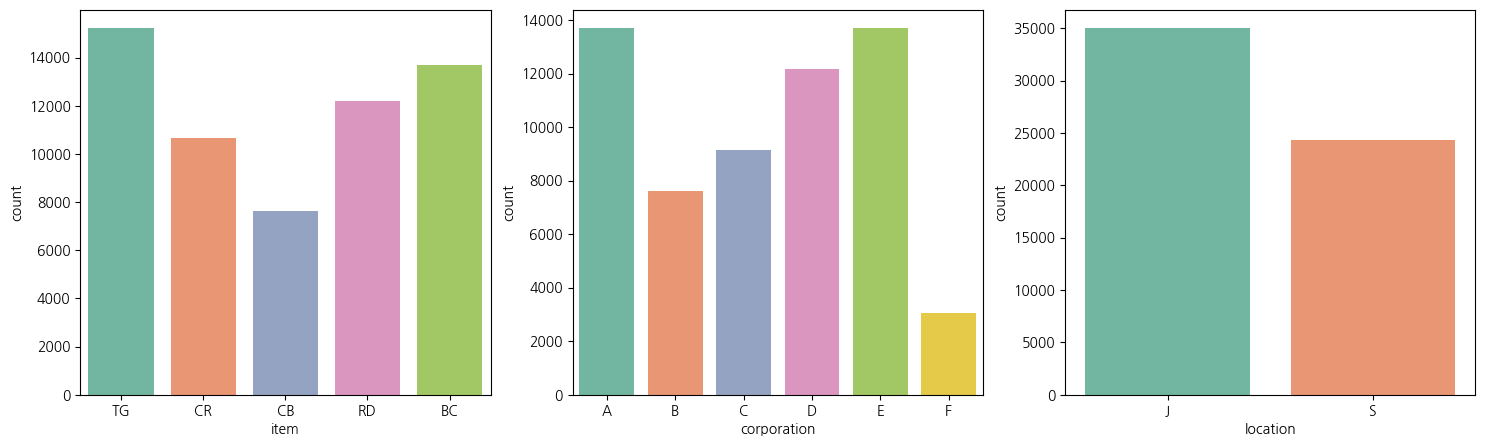

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=train, x="item", ax=axes[0], palette="Set2")
sns.countplot(data=train, x="corporation", ax=axes[1], palette="Set2")
sns.countplot(data=train, x="location", ax=axes[2], palette="Set2")
plt.show()

## 5. 타겟(Price) 변수 분포

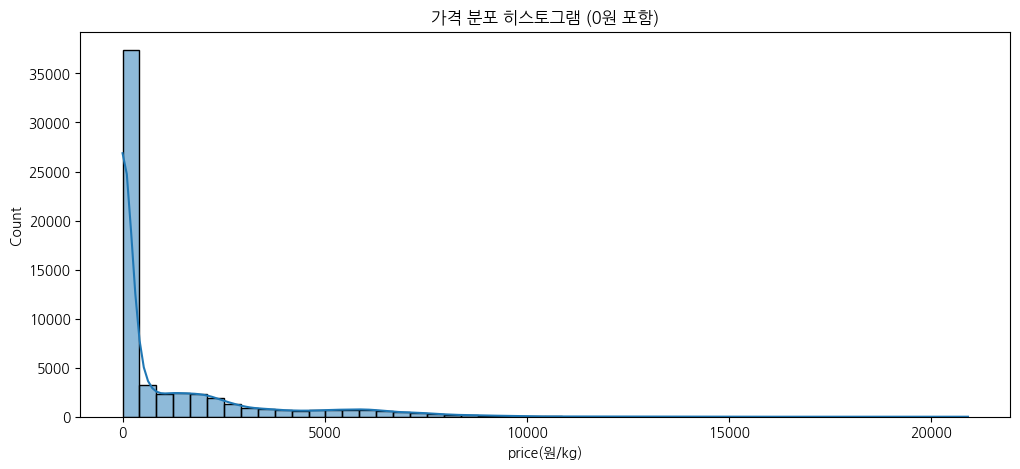

In [30]:
plt.figure(figsize=(12, 5))
sns.histplot(train["price(원/kg)"], bins=50, kde=True)
plt.title("가격 분포 히스토그램 (0원 포함)")
plt.show()

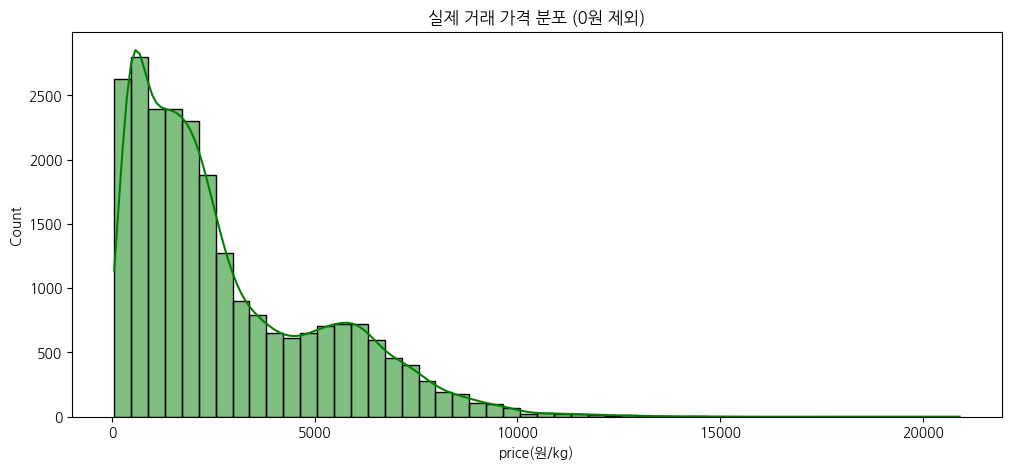

In [31]:
# 0원을 제외한 실제 거래 가격 분포
plt.figure(figsize=(12, 5))
sns.histplot(train[train["price(원/kg)"]>0]["price(원/kg)"], bins=50, kde=True, color="green")
plt.title("실제 거래 가격 분포 (0원 제외)")
plt.show()

## 6. 시계열 분석

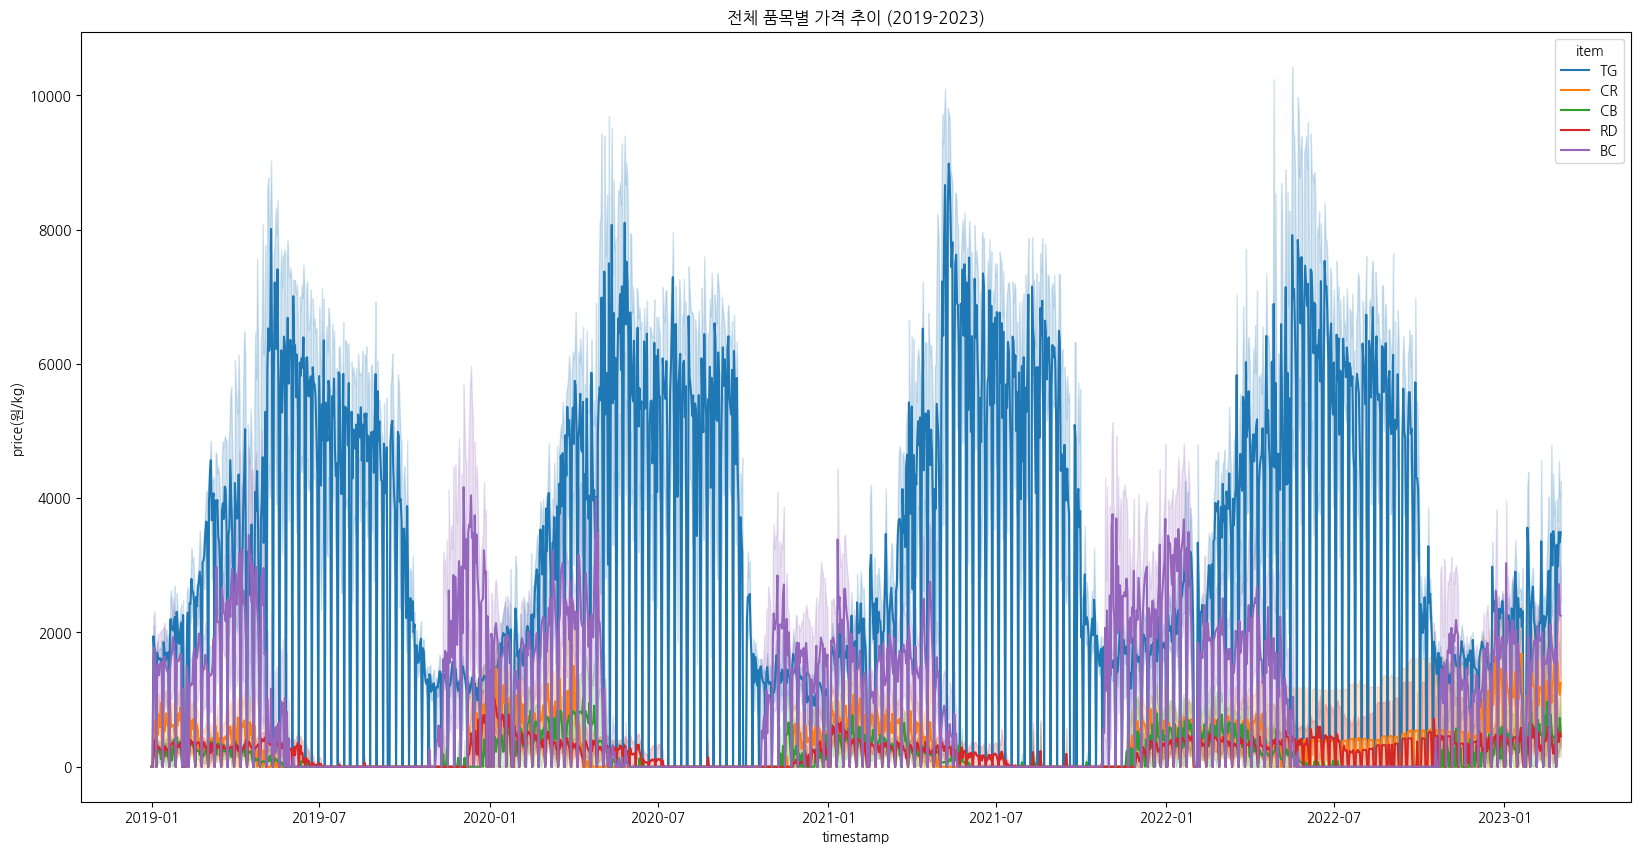

In [32]:
# 품목별 전체 시계열 추이
plt.figure(figsize=(20, 10))
sns.lineplot(data=train, x="timestamp", y="price(원/kg)", hue="item")
plt.title("전체 품목별 가격 추이 (2019-2023)")
plt.show()

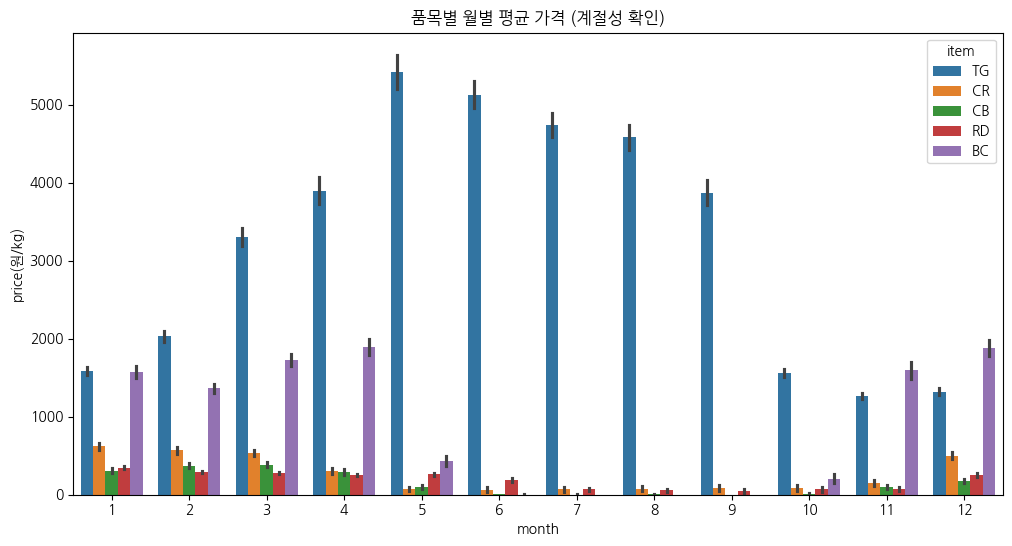

In [33]:
# 월별 평균 가격 패턴 (Seasonality)
train["month"] = train["timestamp"].dt.month
plt.figure(figsize=(12, 6))
sns.barplot(data=train, x="month", y="price(원/kg)", hue="item")
plt.title("품목별 월별 평균 가격 (계절성 확인)")
plt.show()

## 7. 요일 및 휴무일 분석

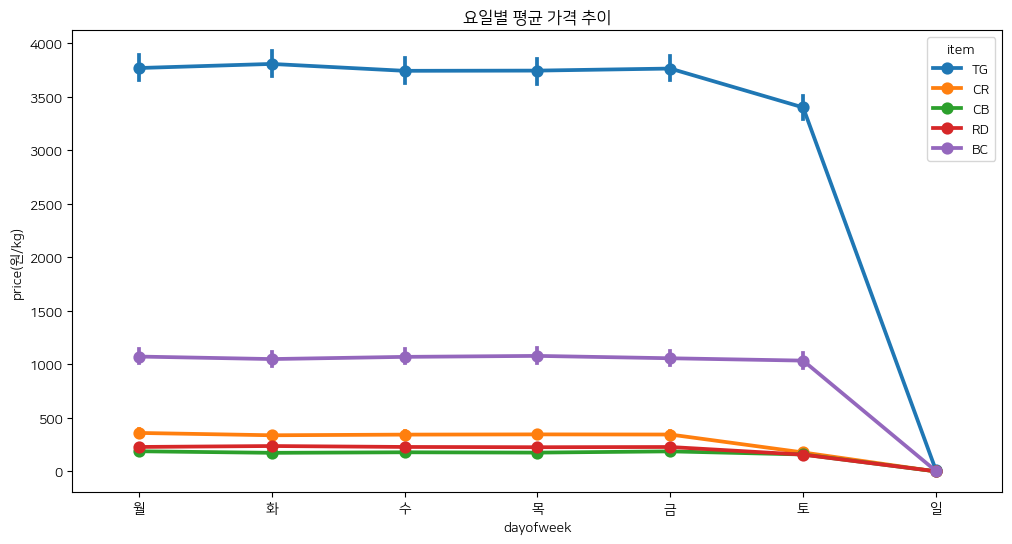

In [4]:
train["dayofweek"] = train["timestamp"].dt.dayofweek
plt.figure(figsize=(12, 6))
sns.pointplot(data=train, x="dayofweek", y="price(원/kg)", hue="item")
plt.xticks(range(7), ["월","화","수","목","금","토","일"])
plt.title("요일별 평균 가격 추이")
plt.show()

In [5]:
# 일요일 0원 비중 확인
sun_zero = train[train["dayofweek"]==6]["price(원/kg)"].value_counts(normalize=True).get(0, 0)
print(f"일요일 가격이 0원일 확률: {sun_zero*100:.2f}%")

일요일 가격이 0원일 확률: 99.75%


설정된 폰트: NanumSquare


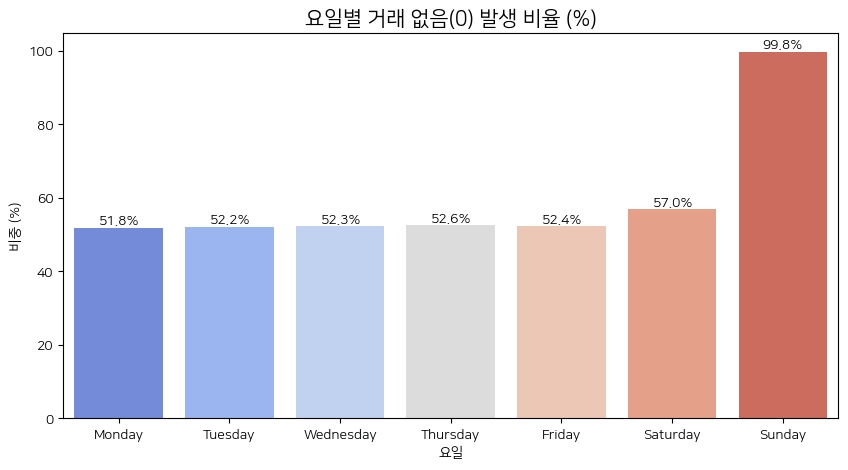

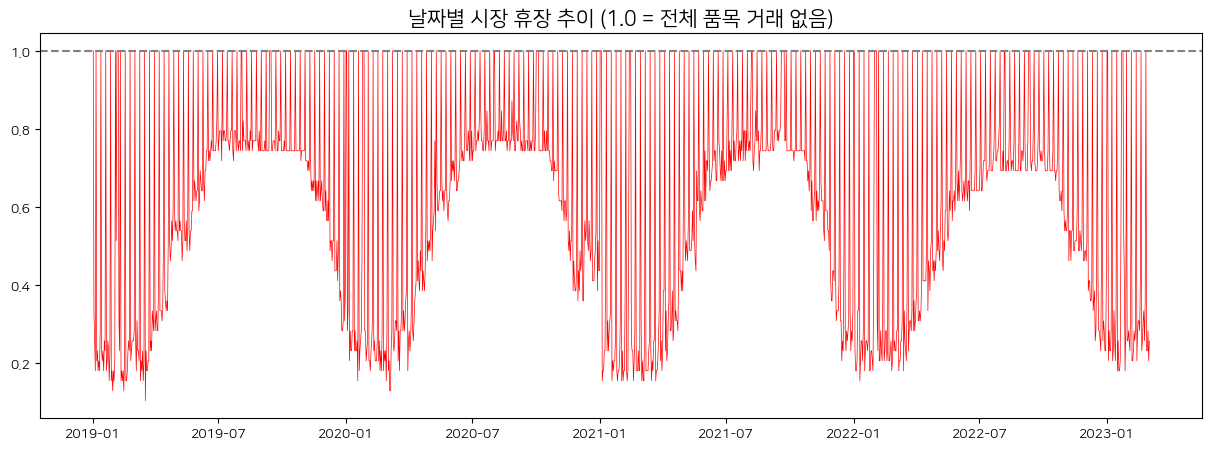

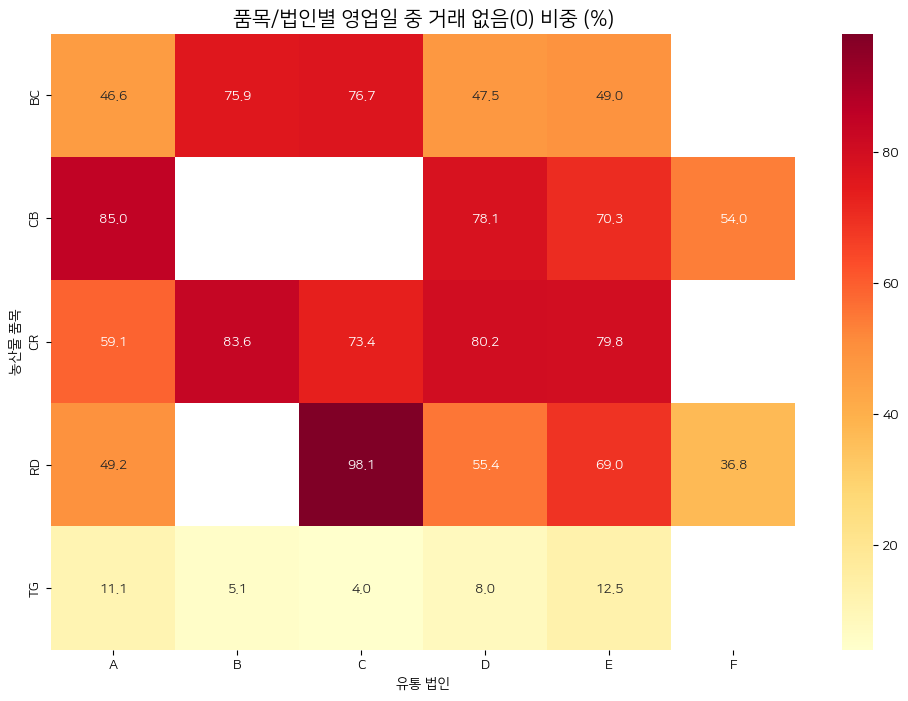

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# --- [폰트 설정] 시스템 내 한글 폰트 자동 탐색 ---
def set_korean_font():
    # 리눅스/코랩에서 주로 사용하는 나눔 폰트 탐색
    font_list = fm.findSystemFonts(fontpaths=None, fontext='ttf')
    nanum_fonts = [f for f in font_list if 'Nanum' in f or 'Gothic' in f]
    
    if nanum_fonts:
        # 가장 첫 번째 찾은 한글 폰트 적용
        font_name = fm.FontProperties(fname=nanum_fonts[0]).get_name()
        plt.rc('font', family=font_name)
        print(f"설정된 폰트: {font_name}")
    else:
        # 폰트를 못 찾을 경우 기본 설정 (그래도 깨진다면 아래 설치 명령어 참고)
        plt.rc('font', family='DejaVu Sans')
        print("한글 폰트를 찾지 못했습니다. 시스템에 폰트 설치가 필요합니다.")
        
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

set_korean_font()

# 2. 데이터 로드 및 전처리
train = pd.read_csv('train.csv')
train['timestamp'] = pd.to_datetime(train['timestamp'])
train['day_name'] = train['timestamp'].dt.day_name()
train['is_zero'] = (train['price(원/kg)'] == 0) & (train['supply(kg)'] == 0)

# --- 시각화 1: 요일별 0 데이터 발생 확률 ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_analysis = train.groupby('day_name')['is_zero'].mean().reindex(day_order).reset_index()
dow_analysis['is_zero'] = dow_analysis['is_zero'] * 100

plt.figure(figsize=(10, 5))
# palette 경고 해결을 위해 hue와 legend 설정 추가
sns.barplot(data=dow_analysis, x='day_name', y='is_zero', hue='day_name', palette='coolwarm', legend=False)
plt.title('요일별 거래 없음(0) 발생 비율 (%)', fontsize=15)
plt.ylabel('비중 (%)')
plt.xlabel('요일')

for i, v in enumerate(dow_analysis['is_zero']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.show()

# --- 시각화 2: 날짜별 시장 휴장 추이 ---
daily_zero_ratio = train.groupby('timestamp')['is_zero'].mean()
plt.figure(figsize=(15, 5))
plt.plot(daily_zero_ratio.index, daily_zero_ratio.values, color='red', linewidth=0.5)
plt.title('날짜별 시장 휴장 추이 (1.0 = 전체 품목 거래 없음)', fontsize=15)
plt.axhline(y=1.0, color='gray', linestyle='--')
plt.show()

# --- 시각화 3: 품목/법인별 영업일 중 0 데이터 비중 (히트맵) ---
market_holidays = daily_zero_ratio[daily_zero_ratio == 1.0].index
working_days_df = train[~train['timestamp'].isin(market_holidays)]
item_corp_zeros = working_days_df.groupby(['item', 'corporation'])['is_zero'].mean().unstack() * 100

plt.figure(figsize=(12, 8))
sns.heatmap(item_corp_zeros, annot=True, fmt=".1f", cmap='YlOrRd')
plt.title('품목/법인별 영업일 중 거래 없음(0) 비중 (%)', fontsize=15)
plt.xlabel('유통 법인')
plt.ylabel('농산물 품목')
plt.show()

1. 요일별 0 데이터 비중 (Zero Value % by Day of Week)

* 해석: 일요일(Sunday)은 99.8% 확률로 데이터가 0입니다. 즉, 일요일은 경매가 거의 열리지 않는 '공식 휴무일'입니다. 반면 토요일도 50%가 넘는 높은 수치를 보이는데, 이는 일부 법인만 운영하거나 조기 마감하는 특성을 보여줍니다.

2. 날짜별 0 데이터 비율 (Daily Ratio of Zero Values)
* 해석: 그래프에서 위쪽 끝(1.0)에 닿아 있는 선들이 **'시장 전체 휴장일'**입니다.

* 주기적으로 발생하는 일요일 외에도, 설날이나 추석 연휴 기간에 모든 품목의 거래가 멈추는 구간이 시각적으로 뚜렷하게 나타납니다. 모델 학습 시 이 '빨간 선'이 1.0인 날짜들을 따로 추출해 '휴장일' 변수로 만들면 효과적입니다.

3. 품목 및 법인별 0 데이터 비중 (Heatmap)
* 해석 (휴장일 제외): 시장이 열린 날인데도 왜 0이 나올까요? 이 히트맵은 그 답을 보여줍니다.

* 예를 들어 **RD(무)**의 경우 특정 법인(C, D, E 등)에서 0의 비중이 매우 높습니다. 이는 해당 법인이 무를 아예 취급하지 않거나, 아주 가끔만 취급한다는 뜻입니다.

* **TG(감귤)**는 상대적으로 0의 비중이 낮아(색이 연함) 다른 품목에 비해 꾸준히 거래가 일어나는 효자 품목임을 알 수 있습니다.

## 8. 공급량(Supply) 분석

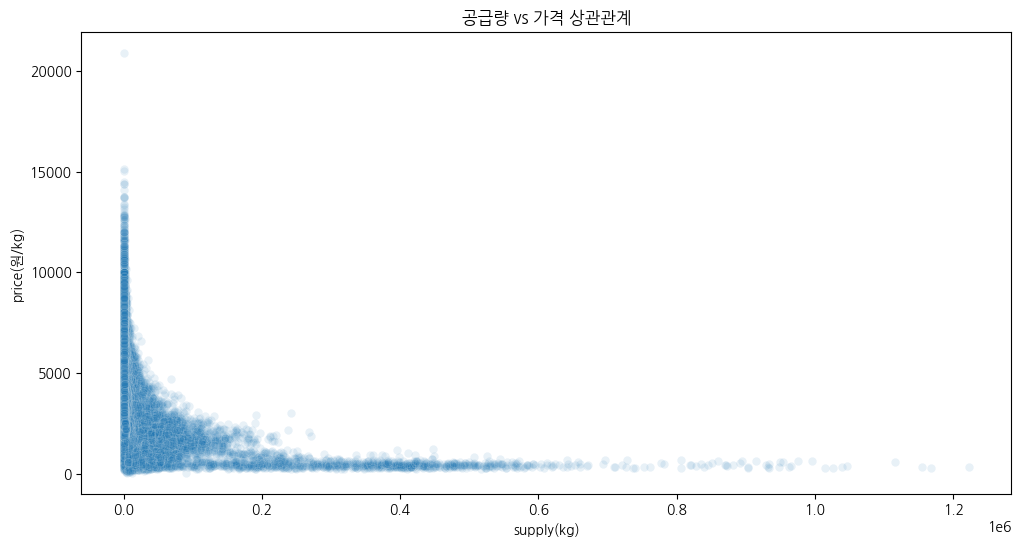

In [36]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=train[train["price(원/kg)"]>0], x="supply(kg)", y="price(원/kg)", alpha=0.1)
plt.title("공급량 vs 가격 상관관계")
plt.show()

## 9. 이상치(Outlier) 분석

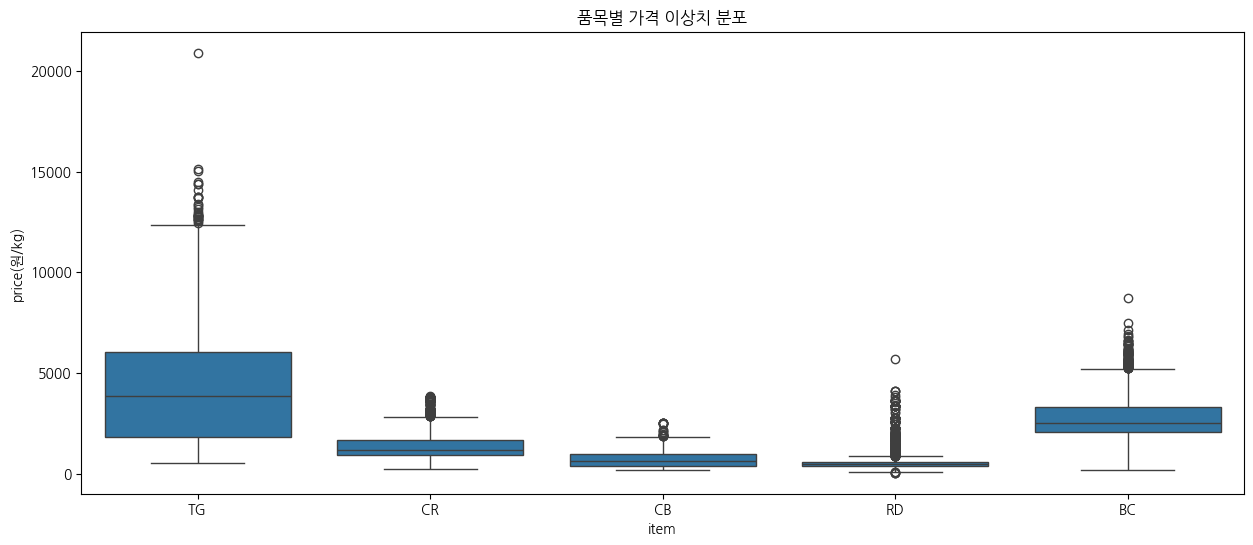

In [37]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=train[train["price(원/kg)"]>0], x="item", y="price(원/kg)")
plt.title("품목별 가격 이상치 분포")
plt.show()

## 10. 상관관계 분석

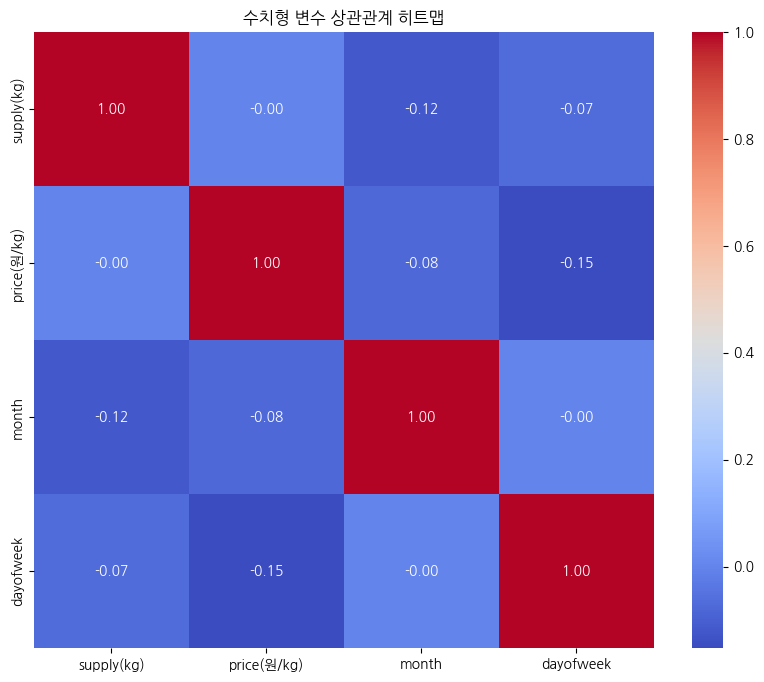

In [38]:
plt.figure(figsize=(10, 8))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("수치형 변수 상관관계 히트맵")
plt.show()

## 11. 법인/지역별 정밀 분석

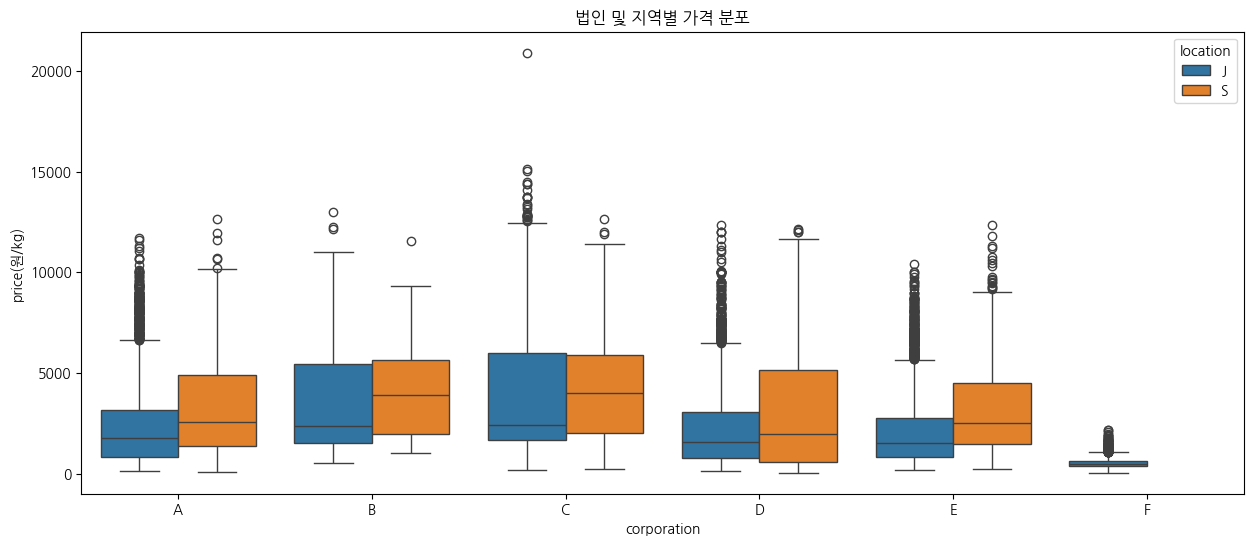

In [39]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=train[train["price(원/kg)"]>0], x="corporation", y="price(원/kg)", hue="location")
plt.title("법인 및 지역별 가격 분포")
plt.show()

## 12. 분석 결론 및 모델링 전략

1. **강력한 계절성**: 월별 가격 차이가 뚜렷함. 달(Month) 피처 중요.
2. **일요일 휴무**: 일요일은 거의 100% 가격이 0임. 후처리 필수.
3. **품목별 상이함**: TG(감귤)와 다른 품목은 스케일과 시기가 완전히 다름. 개별 모델링 고려.
4. **공급량 영향**: 공급량이 적을 때 고가격 이상치가 집중됨.